# Importação das bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

# Configuração global para os gráficos

In [3]:
# Configuração para os gráficos
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Carregando dataframe e verificando tipos de dados

In [4]:
df = pd.read_csv("ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
# Verificando mais informações sobre as colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [6]:
# Apagar colunas que não serão úteis nessa análise
df.drop(["Booking ID", "Customer ID", "Pickup Location", "Drop Location"], axis=1, inplace=True)

In [7]:
# Obtendo mais informações sobre colunas numéricas
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [8]:
# Criar coluna com formato full datetime
df["Full Datetime"] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), format='%Y-%m-%d %H:%M:%S')
df["Full Datetime"].head()

0   2024-03-23 12:29:38
1   2024-11-29 18:01:39
2   2024-08-23 08:56:10
3   2024-10-21 17:17:25
4   2024-09-16 22:08:00
Name: Full Datetime, dtype: datetime64[us]

In [9]:
print("Data mínima: ", df["Full Datetime"].min(), "\nData máxima:", df["Full Datetime"].max())

Data mínima:  2024-01-01 00:19:34 
Data máxima: 2024-12-30 23:36:11


# Explorando os dados

## Distribuição temporal das corridas

### Distribuição de corridas por mês

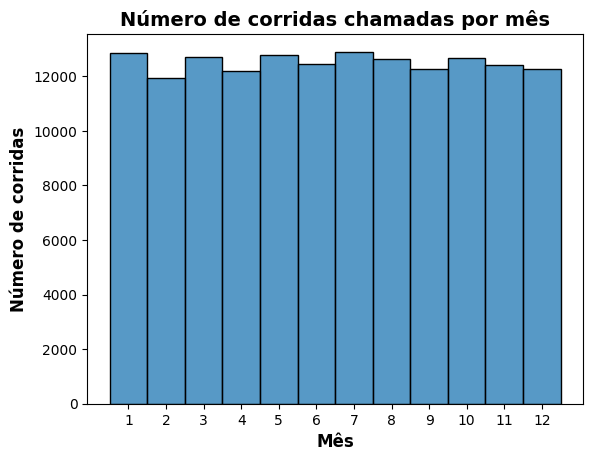

In [10]:
sns.histplot(df["Full Datetime"].dt.month, discrete=True)
plt.title("Número de corridas chamadas por mês")
plt.xlabel("Mês")
plt.xticks(range(1,13))
plt.ylabel("Número de corridas")
plt.savefig('images/rides-by-month.png')
plt.show()

### Distribuição de corridas ao longo do mês

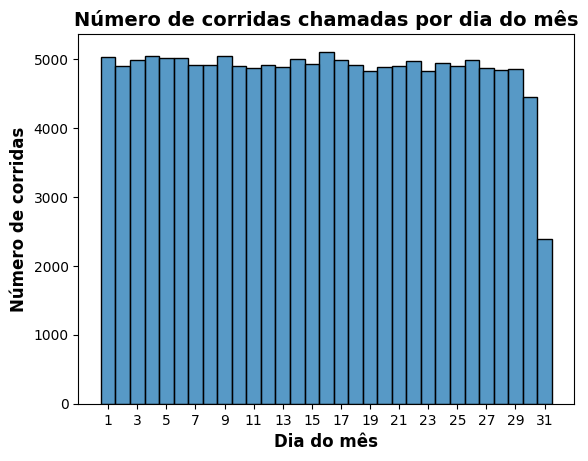

In [11]:
sns.histplot(df["Full Datetime"].dt.day, discrete=True)
plt.title("Número de corridas chamadas por dia do mês")
plt.xlabel("Dia do mês")
plt.xticks(range(1,32,2))
plt.ylabel("Número de corridas")
plt.savefig('images/rides-by-day-of-month.png')
plt.show()

### Distribuição de corridas por dia da semana

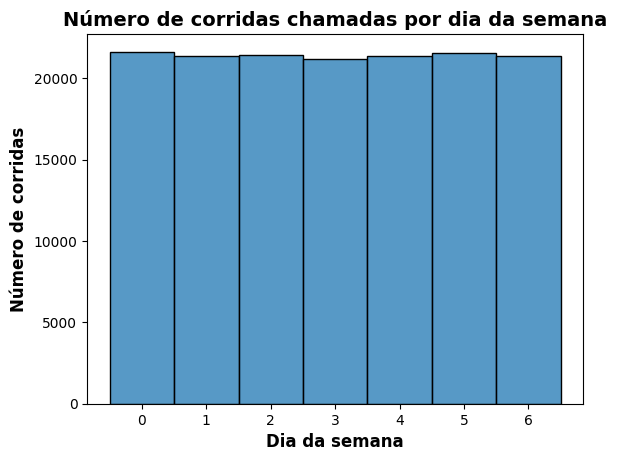

In [12]:
sns.histplot(df["Full Datetime"].dt.dayofweek, discrete=True)
plt.title("Número de corridas chamadas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Número de corridas")
plt.savefig('images/rides-by-dayofweek.png')
plt.show()

### Distribuição de corridas por hora do dia

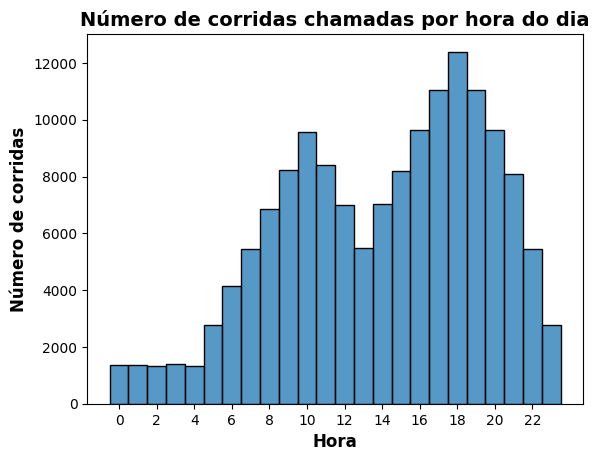

In [13]:
# Plotar numero de corridas chamadas por horas do dia

sns.histplot(df["Full Datetime"].dt.hour, discrete=True)
plt.title("Número de corridas chamadas por hora do dia")
plt.xlabel("Hora")
plt.xticks(range(0,24,2))
plt.ylabel("Número de corridas")
plt.savefig('images/rides-by-hour.png')
plt.show()

## Explorando status de corridas e cancelamentos

In [14]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

### Analisando proporção de cancelamentos

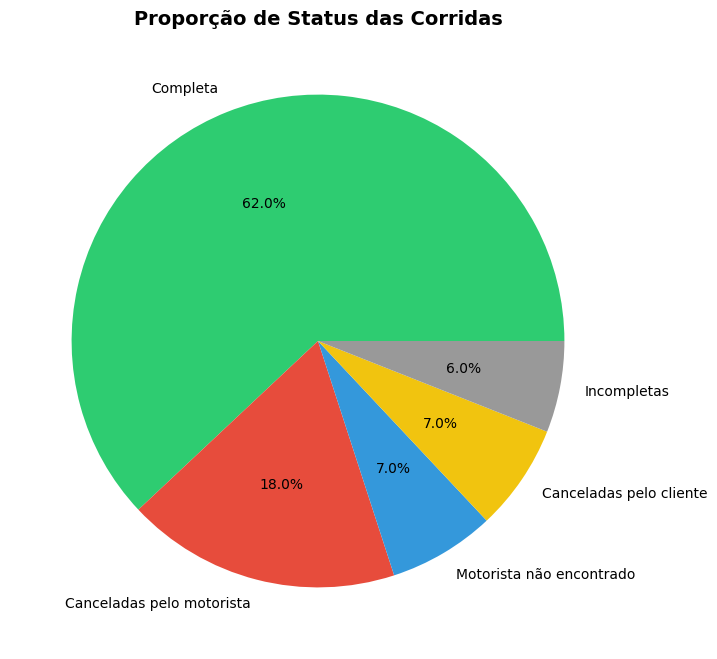

In [72]:
# Distribuição de status das corridas completadas e canceladas

status_counts = df["Booking Status"].value_counts()
status_labels_pt = ["Completa", "Canceladas pelo motorista", "Motorista não encontrado", "Canceladas pelo cliente", "Incompletas"]

plt.figure(figsize=(8, 8))
plt.pie(
    status_counts,
    labels = status_labels_pt,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#999']
)
plt.title("Proporção de Status das Corridas")
plt.savefig("images/pie-chart-status.png")
plt.show()

### Verificando relação entre horário e proporção de cancelamentos

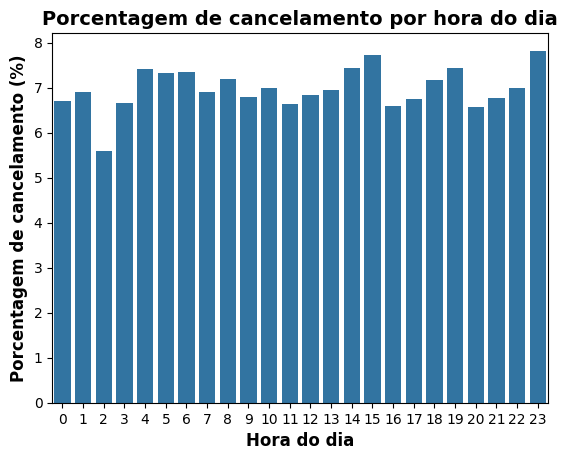

In [16]:
# Verificar se há um horário onde os clientes cancelam mais

total_por_hora = df["Full Datetime"].dt.hour.value_counts().sort_index()

canceladas_por_clientes = df[df["Booking Status"] == "Cancelled by Customer"]

canceladas_por_hora_por_clientes = canceladas_por_clientes["Full Datetime"].dt.hour.value_counts().sort_index()

proporcao_cancelamento = canceladas_por_hora_por_clientes / total_por_hora *100

sns.barplot(x=proporcao_cancelamento.index, y = proporcao_cancelamento.values)
plt.title("Porcentagem de cancelamento por hora do dia")
plt.xlabel("Hora do dia")
plt.xticks(range(24))
plt.ylabel("Porcentagem de cancelamento (%)")

plt.savefig("images/cancel-percent-per-hour.png")
plt.show()

### Verificando relação entre tempo de espera e cancelamento

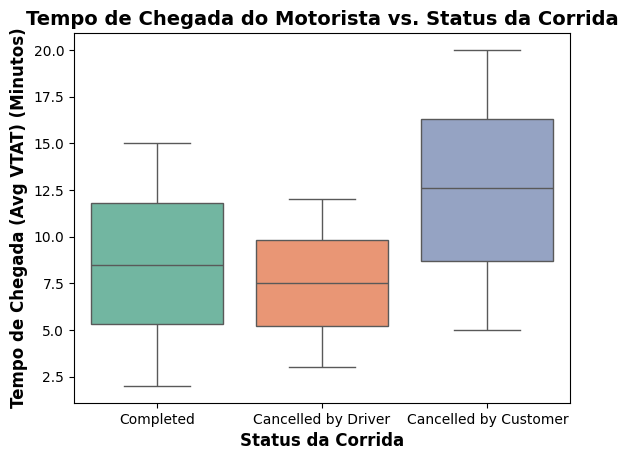

In [71]:
# Verificar relação entre tempo de chegada do motorista e cancelamentos por clientes

df_comparacao = df[df["Booking Status"].isin(["Completed", "Cancelled by Customer", "Cancelled by Driver"])]

sns.boxplot(data=df_comparacao, x="Booking Status", y="Avg VTAT", palette="Set2", hue="Booking Status")
plt.title("Tempo de Chegada do Motorista vs. Status da Corrida")
plt.xlabel("Status da Corrida")
plt.ylabel("Tempo de Chegada (Avg VTAT) (Minutos)")

plt.savefig("images/avtat-box.png")
plt.show()

## Correlação entre variáveis numéricas

In [59]:
df_completas = df[df["Booking Status"] == "Completed"]

df_corr = df_completas[["Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance", "Driver Ratings", "Customer Rating"]]

corr = df_corr.corr()

corr

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
Avg VTAT,1.000000,0.001501,0.002823,0.003858,-0.005439,-0.003945
Avg CTAT,0.001501,1.000000,0.000740,0.001486,0.000807,0.001000
Booking Value,0.002823,0.000740,1.000000,0.005668,-0.000249,-0.000287
Ride Distance,0.003858,0.001486,0.005668,1.000000,-0.001875,0.004514
Driver Ratings,-0.005439,0.000807,-0.000249,-0.001875,1.000000,-0.001010
Customer Rating,-0.003945,0.001000,-0.000287,0.004514,-0.001010,1.000000


In [73]:
# Remover diagonal para melhor visualização no heatmap (eliminar correlação 1)

corr.replace(1, np.nan, inplace=True)

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
Avg VTAT,NaN,0.001501,0.002823,0.003858,-0.005439,-0.003945
Avg CTAT,0.001501,NaN,0.000740,0.001486,0.000807,0.001000
Booking Value,0.002823,0.000740,NaN,0.005668,-0.000249,-0.000287
Ride Distance,0.003858,0.001486,0.005668,NaN,-0.001875,0.004514
Driver Ratings,-0.005439,0.000807,-0.000249,-0.001875,NaN,-0.001010
Customer Rating,-0.003945,0.001000,-0.000287,0.004514,-0.001010,NaN


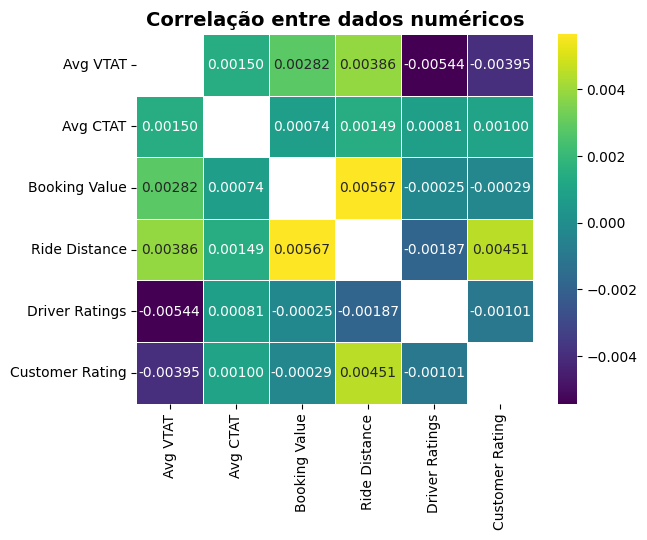

In [75]:
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".5f", 
    linewidths=.5,
    cmap="viridis"
)
plt.title("Correlação entre dados numéricos")

plt.savefig("images/corr-heatmap.png")
plt.show()